Epoch 500: Loss = 6.83774e-02
Epoch 1000: Loss = 6.01286e-03
Epoch 1500: Loss = 1.84253e-03
Epoch 2000: Loss = 9.96704e-04
Epoch 2500: Loss = 6.52564e-04
Epoch 3000: Loss = 5.21155e-04
Epoch 3500: Loss = 3.46909e-04
Epoch 4000: Loss = 2.65695e-04
Epoch 4500: Loss = 2.07028e-04
Epoch 5000: Loss = 1.16401e-03
Epoch 5500: Loss = 1.26050e-04
Epoch 6000: Loss = 1.02565e-04
Epoch 6500: Loss = 8.31150e-05
Epoch 7000: Loss = 6.99892e-05
Epoch 7500: Loss = 6.76675e-05
Epoch 8000: Loss = 5.51613e-05
Epoch 8500: Loss = 4.77971e-05
Epoch 9000: Loss = 4.28927e-05
Epoch 9500: Loss = 3.88241e-05
Epoch 10000: Loss = 3.57243e-05


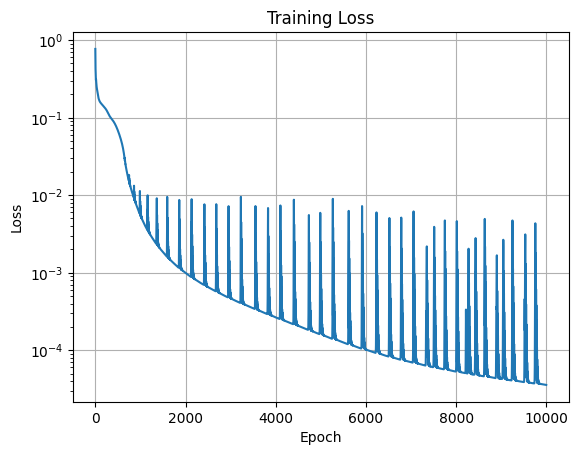

In [17]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from src.pinn_model import PINN
from src.data_generator import (
    generate_collocation_points,
    generate_boundary_points,
    generate_initial_condition
)

# ----- Settings -----
N_colloc = 10000
N_bound = 2000
N_init = 2000
learning_rate = 0.001
epochs = 10000

# Initial condition function u(x, 0) = sin(pi x)
u0_fn = lambda x: np.sin(np.pi * x)

# ----- Generate training data -----
X_colloc = tf.convert_to_tensor(generate_collocation_points(N_colloc), dtype=tf.float32)
X_colloc_var = tf.Variable(X_colloc)
X_bound = tf.convert_to_tensor(generate_boundary_points(N_bound), dtype=tf.float32)
X_init_np, u_init_np = generate_initial_condition(N_init, u0_fn=u0_fn)
X_init = tf.convert_to_tensor(X_init_np, dtype=tf.float32)
u_init = tf.convert_to_tensor(u_init_np, dtype=tf.float32)

# ----- Model -----
model = PINN()

# ----- Optimizer -----
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
loss_history = []

# ----- Training Step -----
@tf.function
def train_step():
    with tf.GradientTape() as tape:
        # Physics loss
        f = model.compute_pde_residual(X_colloc_var)
        loss_f = tf.reduce_mean(tf.square(f))

        # Boundary loss
        u_bound = model(X_bound)
        loss_b = tf.reduce_mean(tf.square(u_bound))  # u=0 at boundaries

        # Initial condition loss
        u_pred_init = model(X_init)
        loss_i = tf.reduce_mean(tf.square(u_pred_init - u_init))

        total_loss = loss_f + loss_b + loss_i

    grads = tape.gradient(total_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return total_loss

# ----- Training Loop -----
for epoch in range(1, epochs + 1):
    loss = train_step()
    loss_history.append(loss.numpy())
    if epoch % 500 == 0:
        print(f"Epoch {epoch}: Loss = {loss.numpy():.5e}")

# ----- Plot Loss History -----
plt.plot(loss_history)
plt.yscale('log')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()


x_vals = np.linspace(0, 1, 100)
t_vals = np.linspace(0, 1, 100)
X, T = np.meshgrid(x_vals, t_vals)
XT = np.hstack((X.flatten()[:, None], T.flatten()[:, None]))
XT_tensor = tf.convert_to_tensor(XT, dtype=tf.float32)


u_pred = model(XT_tensor)
U = u_pred.numpy().reshape(100, 100)



X shape: (100, 100)
T shape: (100, 100)
U shape: (100, 100)


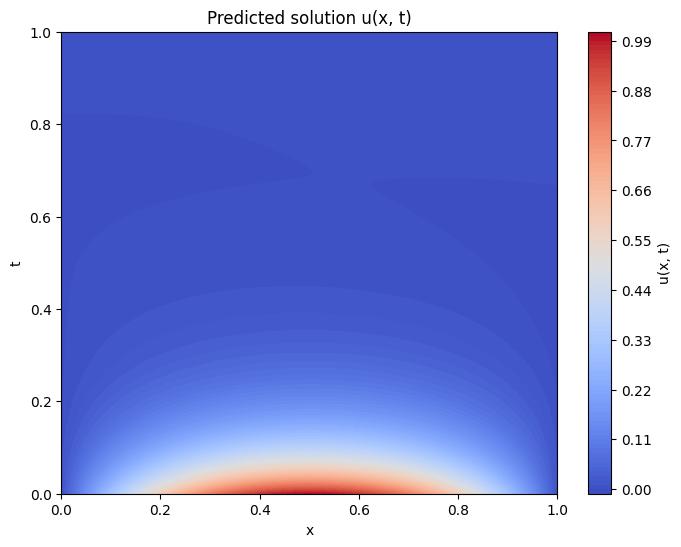

X shape: (100, 100)
T shape: (100, 100)


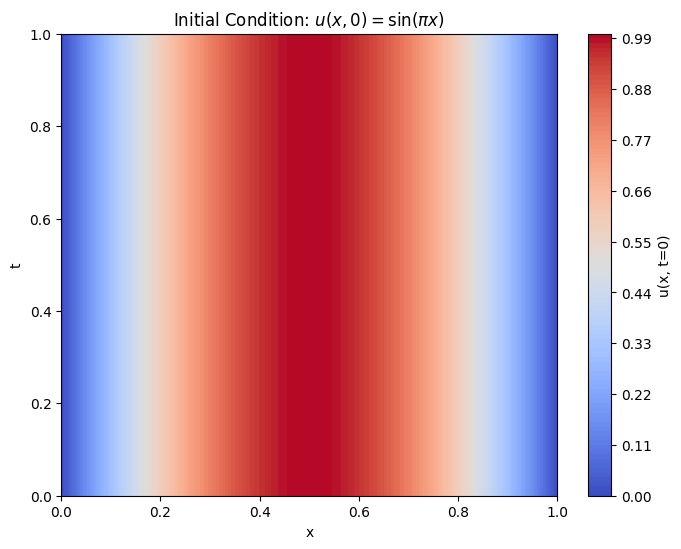

X shape: (100, 100)
T shape: (100, 100)
U_exact shape: (100, 100)


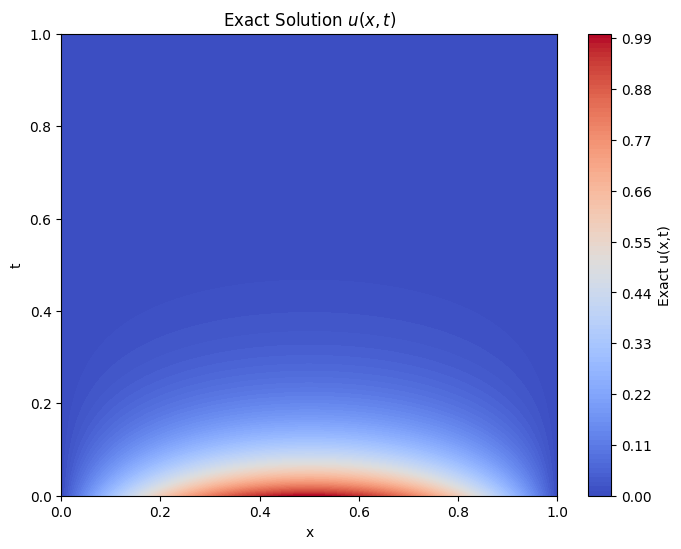

In [ ]:

X, T = np.meshgrid(x_vals, t_vals)

print("X shape:", X.shape)
print("T shape:", T.shape)
print("U shape:", U.shape)
plt.figure(figsize=(8, 6))
plt.contourf(X, T, U, 100, cmap='coolwarm')
plt.colorbar(label='u(x, t)')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Predicted solution u(x, t)')
plt.show()


u_pred_np = u_pred.numpy().flatten()           # shape (10000,)
u_exact = np.sin(np.pi * XT[:, 0]) * np.exp(-np.pi**2 * XT[:, 1])  # already shape (10000,)
error = np.abs(u_pred_np - u_exact) 



# Compute the initial condition on the same grid
U0 = np.sin(np.pi * X)  # X has shape (100, 100)

plt.figure(figsize=(8, 6))
print("X shape:", X.shape)
print("T shape:", T.shape)
plt.contourf(X, T, U0, 100, cmap='coolwarm')
plt.colorbar(label='u(x, t=0)')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Initial Condition: $u(x, 0) = \sin(\pi x)$')
plt.show()



plt.figure(figsize=(8, 6))
U_exact = u_exact.reshape(100, 100)
print("X shape:", X.shape)
print("T shape:", T.shape)
print("U_exact shape:", U_exact.shape)
plt.contourf(X, T, U_exact, 100,cmap='coolwarm')
plt.colorbar(label='Exact u(x,t)')
plt.title('Exact Solution $u(x, t)$')
plt.xlabel('x')
plt.ylabel('t')
plt.show()


In [49]:
print(U)

[[0.00033652 0.03168558 0.06305289 ... 0.0645754  0.03321158 0.00183379]
 [0.00351494 0.03184622 0.06017595 ... 0.0599094  0.03149541 0.00305929]
 [0.00555991 0.03117832 0.0567837  ... 0.05555322 0.02983403 0.00408914]
 ...
 [0.00104933 0.00103729 0.00102525 ... 0.00291883 0.00296109 0.00300484]
 [0.00111645 0.00110357 0.0010901  ... 0.00290644 0.00294697 0.00298851]
 [0.00118285 0.00116848 0.0011546  ... 0.00288677 0.00292533 0.00296497]]


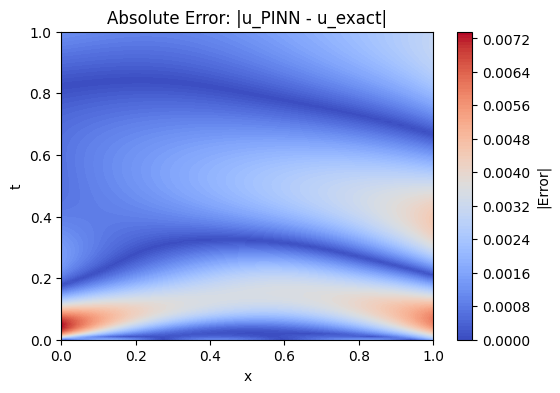

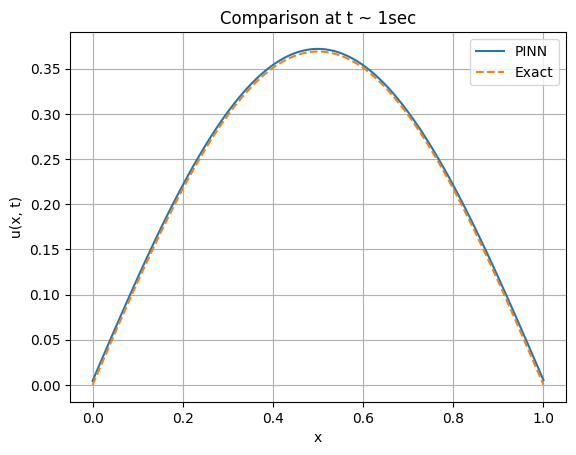

[0.00000000e+00 3.17279335e-02 6.34239197e-02 ... 3.28048721e-06
 1.64106981e-06 6.33426344e-21]


In [55]:

Error = error.reshape(100, 100)
plt.figure(figsize=(6, 4))
plt.contourf(X, T, Error, 100, cmap='coolwarm')
plt.colorbar(label='|Error|')
plt.title('Absolute Error: |u_PINN - u_exact|')
plt.xlabel('x')
plt.ylabel('t')
plt.show()

u_exact = np.sin(np.pi * XT[:, 0]) * np.exp(-np.pi**2 * XT[:, 1]) 

mid_idx = 10
plt.plot(x_vals, U[mid_idx, :], label="PINN")
plt.plot(x_vals, np.sin(np.pi * x_vals) * np.exp(-np.pi**2 * t_vals[mid_idx]), label="Exact", linestyle='dashed')
plt.xlabel("x")
plt.ylabel("u(x, t)")
plt.legend()
plt.title("Comparison at t ~ 1sec")
plt.grid(True)
plt.show()
print(u_exact)



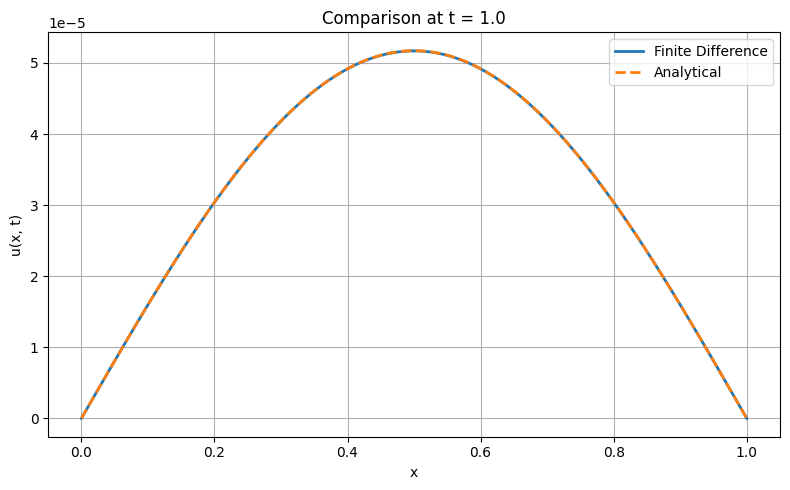

RuntimeError: No mappable was found to use for colorbar creation. First define a mappable such as an image (with imshow) or a contour set (with contourf).

<Figure size 800x500 with 0 Axes>

In [75]:
import numpy as np
import matplotlib.pyplot as plt

# ----- Parameters -----
L = 1.0             # Length of rod
T_max = 1.0         # Total time
Nx = 100            # Spatial grid points
dx = L / (Nx - 1)
x = np.linspace(0, L, Nx)

alpha = 0.4                     # Stability factor
dt = alpha * dx**2             # Time step based on stability condition
Nt = int(T_max / dt)
t = np.linspace(0, T_max, Nt)

# ----- Initialize solution arrays -----
U_fd = np.zeros((Nt, Nx))                      # Finite difference solution
U_fd[0, :] = np.sin(np.pi * x)                 # Initial condition

# ----- Time stepping (explicit FDM) -----
for n in range(0, Nt - 1):
    for i in range(1, Nx - 1):
        U_fd[n+1, i] = U_fd[n, i] + alpha * (U_fd[n, i+1] - 2*U_fd[n, i] + U_fd[n, i-1])

# ----- Analytical solution at all times -----
x= np.linspace(0, 1, 100)
t = np.linspace(0, 1, 100)
X, T = np.meshgrid(x, t)
U_exact = np.sin(np.pi * X) * np.exp(-np.pi**2 * T)

# ----- Error -----
#error = np.abs(U_fd - U_exact)

# ----- Plot Comparison at Final Time -----
plt.figure(figsize=(8, 5))
plt.plot(x, U_fd[-1, :], label='Finite Difference', lw=2)
plt.plot(x, U_exact[-1, :], '--', label='Analytical', lw=2)
plt.title(f'Comparison at t = {T_max}')
plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ----- Error Heatmap -----
plt.figure(figsize=(8, 5))
#plt.contourf(x, t, error, 100, cmap='coolwarm')
plt.colorbar(label='|Error|')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Absolute Error: |FDM - Exact|')
plt.tight_layout()
plt.show()


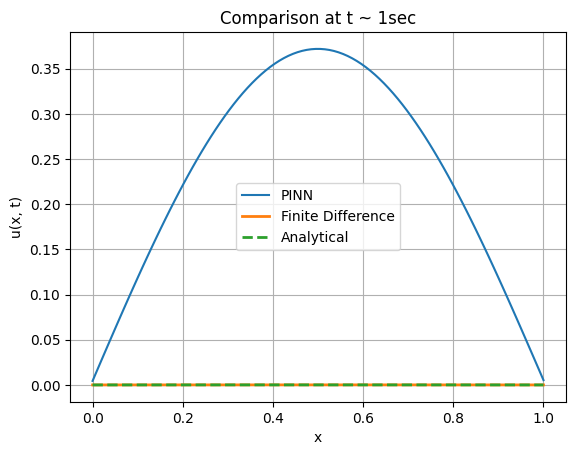

In [77]:
mid_idx = 10
plt.plot(x_vals, U[10, :], label="PINN")
plt.plot(x, U_fd[-1, :], label='Finite Difference', lw=2)
plt.plot(x, U_exact[-1, :], '--', label='Analytical', lw=2)
plt.xlabel("x")
plt.ylabel("u(x, t)")
plt.legend()
plt.title("Comparison at t ~ 1sec")
plt.grid(True)
plt.show()